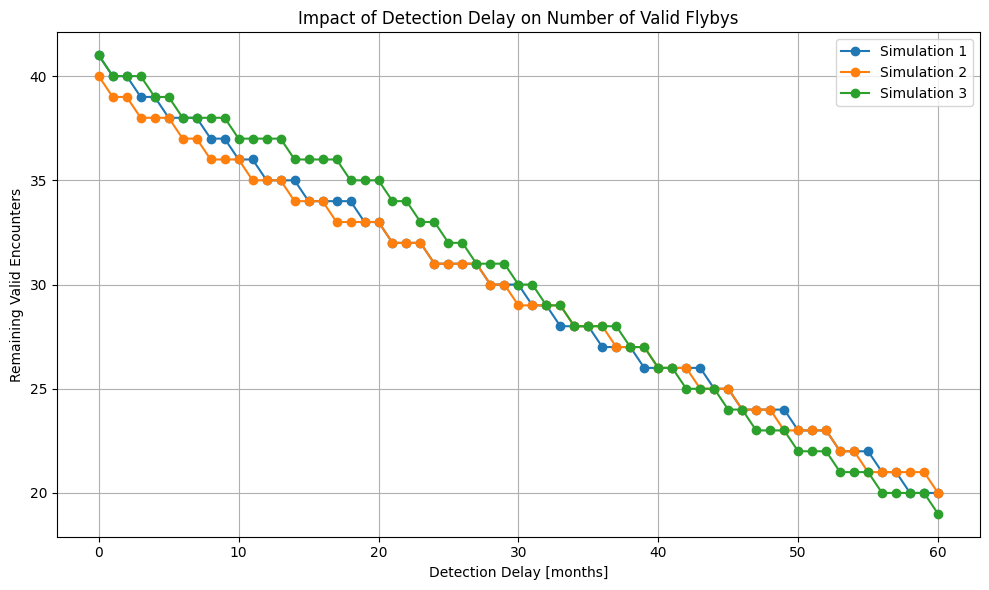

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import re
import os

# Define the function to extract flyby dates from a given orbit file
def extract_flyby_dates(orbit_file_path):
    with open(orbit_file_path, 'r') as f:
        orbit_lines = f.readlines()
    orbit_start_dates = []
    for line in orbit_lines:
        if line.strip() and not line.startswith("#"):
            parts = line.split()
            try:
                orbit_start = datetime.strptime(parts[1] + " " + parts[2], "%Y-%m-%d %H:%M:%S.%f")
                orbit_start_dates.append(orbit_start)
            except:
                continue

    # Every 3rd orbit is assumed to be a transfer orbit (flyby date)
    flyby_dates = [orbit_start_dates[i] for i in range(2, len(orbit_start_dates), 3)]
    return flyby_dates

# Define the function to calculate detection delay impact
def compute_delay_vs_encounters(flyby_dates, delay_range_months):
    base_time = flyby_dates[0]
    delay_months = []
    num_valid_encounters = []
    for delay in delay_range_months:
        new_detection_time = base_time + timedelta(days=30.44 * delay)
        valid_count = sum(fb_date >= new_detection_time for fb_date in flyby_dates)
        delay_months.append(delay)
        num_valid_encounters.append(valid_count)
    return delay_months, num_valid_encounters

# Analyze three orbit files
orbit_files = {
    "Simulation 1": "orbits_list_1.txt",
    "Simulation 2": "orbits_list_2.txt",
    "Simulation 3": "orbits_list_3.txt"
}

delay_range_months = range(0, 61, 1)
results = {}

for label, filepath in orbit_files.items():
    if os.path.exists(filepath):
        flyby_dates = extract_flyby_dates(filepath)
        delays, counts = compute_delay_vs_encounters(flyby_dates, delay_range_months)
        results[label] = (delays, counts)

# Plot all results
plt.figure(figsize=(10, 6))
for label, (delays, counts) in results.items():
    plt.plot(delays, counts, marker='o', linestyle='-', label=label)

plt.title("Impact of Detection Delay on Number of Valid Flybys")
plt.xlabel("Detection Delay [months]")
plt.ylabel("Remaining Valid Encounters")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

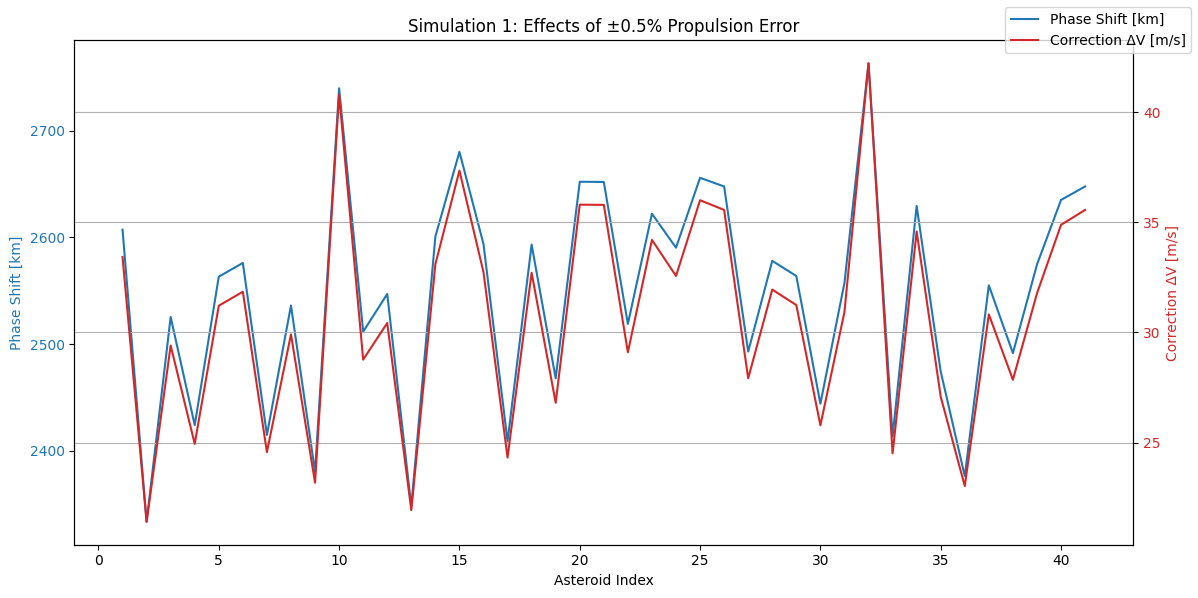

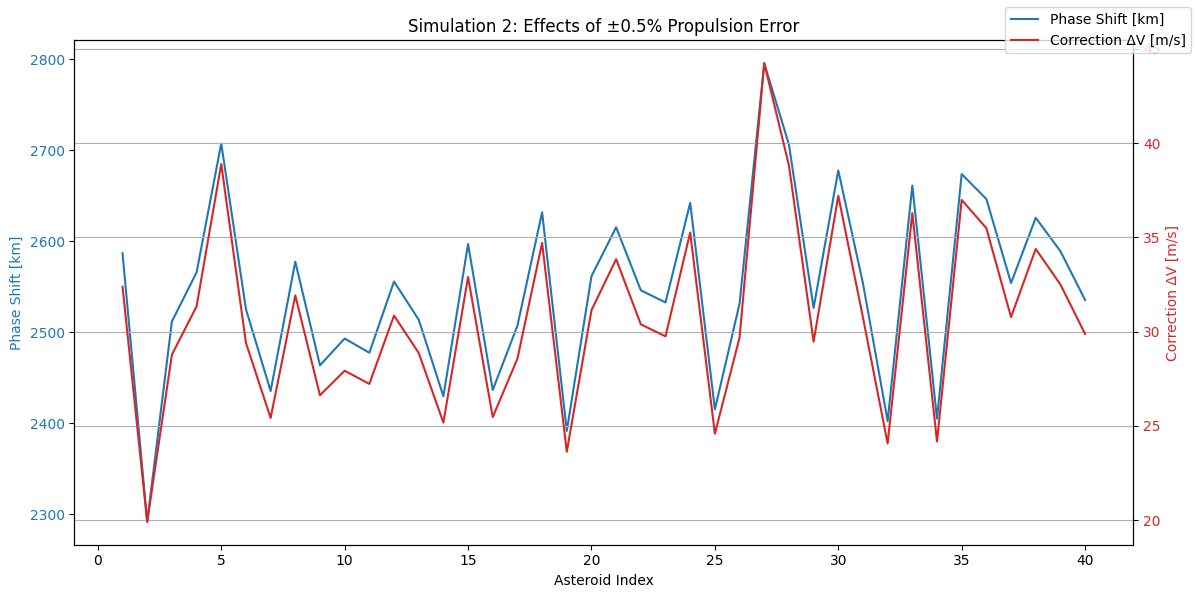

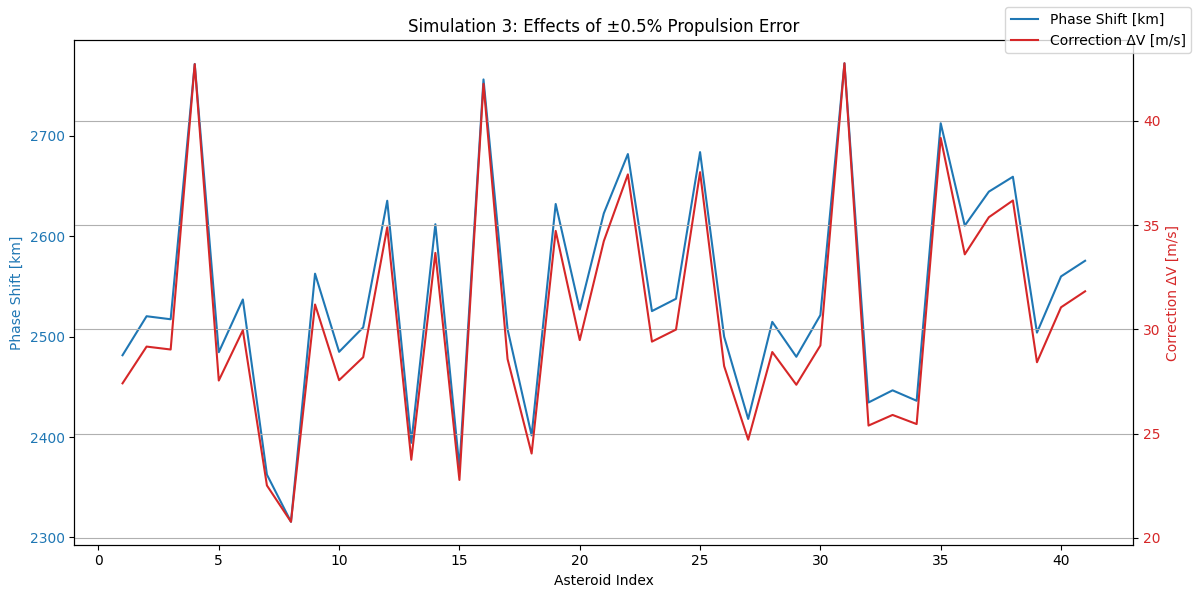

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Constants
mu_earth = 3.986004419e14  # m^3/s^2
delta_v_error_fraction = 0.005  # ±0.5%
time_error = 6 * 24 * 3600  # 6 days in seconds

# File names
nominal_files = ["nominal_sequence_1.txt", "nominal_sequence_2.txt", "nominal_sequence_3.txt"]
orbit_files = ["orbits_list_1.txt", "orbits_list_2.txt", "orbits_list_3.txt"]

# Functions
def extract_dv_values(filepath):
    dv_values = []
    with open(filepath, "r") as f:
        for line in f:
            if "DVT" in line and "Accepted" in line:
                dv_str = line.split("DVT = ")[1].split(" ")[0]
                dv_values.append(float(dv_str))  # in km/s
    return dv_values

def extract_sma_transfer_arcs(filepath):
    sma_list = []
    with open(filepath, "r") as f:
        for idx, line in enumerate(f):
            if line.startswith("#") or len(line.strip()) == 0:
                continue
            parts = line.strip().split()
            try:
                sma = float(parts[5])
                if (idx % 3) == 2:  # every 3rd orbit is transfer
                    sma_list.append(sma)
            except:
                continue
    return sma_list

def compute_phase_and_dv_error(sma_list, dv_list, t_error, error_frac):
    results = []
    for sma, dv in zip(sma_list, dv_list):
        n = np.sqrt(mu_earth / sma**3)  # mean motion [rad/s]
        dtheta_rad = n * t_error * error_frac
        dtheta_deg = np.degrees(dtheta_rad)
        dtheta_km = sma * dtheta_rad  # arc length
        sman = sma - dtheta_km/2
        dvcorr = 20*abs(np.sqrt(mu_earth*(2/sma-1/sman)) - np.sqrt(mu_earth/sma))  # crude tangential maneuver
        results.append((dtheta_deg, dtheta_km/1000, dvcorr))  # m/s
    return results

def run_analysis(nominal_files, orbit_files, t_error, error_frac):
    all_results = []
    for nom_file, orb_file in zip(nominal_files, orbit_files):
        dv_vals = extract_dv_values(nom_file)
        sma_vals = extract_sma_transfer_arcs(orb_file)
        results = compute_phase_and_dv_error(sma_vals[:len(dv_vals)], dv_vals, t_error, error_frac)
        all_results.append(results)
    return all_results

def plot_all(results):
    for sim_idx, data in enumerate(results):
        indices = np.arange(1, len(data)+1)
        dtheta_deg = [x[0] for x in data]
        dtheta_km = [x[1] for x in data]
        dv_corr = [x[2] for x in data]

        fig, ax1 = plt.subplots(figsize=(12, 6))
        # Left Y-axis: Phase Shift
        color = 'tab:blue'
        ax1.set_xlabel("Asteroid Index")
        ax1.set_ylabel("Phase Shift [km]", color=color)
        ax1.plot(indices, dtheta_km, label="Phase Shift [km]", color=color)
        ax1.tick_params(axis='y', labelcolor=color)

        # Right Y-axis: Correction ΔV
        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel("Correction ΔV [m/s]", color=color)
        ax2.plot(indices, dv_corr, label="Correction ΔV [m/s]", color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        plt.title(f"Simulation {sim_idx+1}: Effects of ±0.5% Propulsion Error")
        fig.tight_layout()
        plt.grid(True)
        fig.legend()
        plt.savefig(f"sim{sim_idx+1}_prop_error_analysis.pdf")
        plt.show()
        plt.close()

# Main
if __name__ == "__main__":
    results = run_analysis(nominal_files, orbit_files, time_error, delta_v_error_fraction)
    plot_all(results)

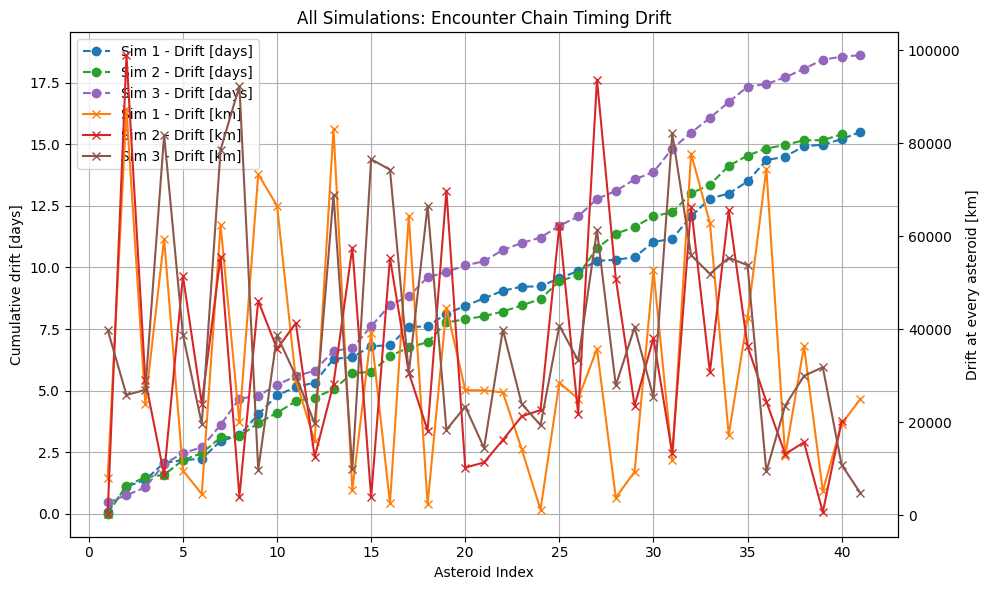

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

mu_earth = 3.986004418e14  # m^3/s^2
vorb = np.sqrt(mu_earth/4e8)

def parse_orbit_file(file_path):
    df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None,
                     names=['Index', 'DateStart', 'DateEnd', 'sma', 'ecc', 'inc', 'raan', 'argperiap', 'theta0'])
    df['sma'] = pd.to_numeric(df['sma'], errors='coerce')
    df['ecc'] = pd.to_numeric(df['ecc'], errors='coerce')
    df = df[['sma', 'ecc']].dropna()
    df = df[df['sma'] > 0]  # discard unphysical or placeholder rows
    df = df.reset_index(drop=True)
    return df

def compute_orbital_period(a_km):
    return 2 * np.pi * np.sqrt(a_km**3 / mu_earth) if a_km > 0 else np.inf

def propagate_drift(orbits_df, time_error_sec=6*86400):
    cumulative_drift = []
    total_drift_sec = 0.0

    for i in range(1, len(orbits_df), 3):  # consider only transfer legs (1, 3, 5,...)
        sma = orbits_df.iloc[i]['sma']
        ecc = orbits_df.iloc[i]['ecc']

        if sma <= 0:
            continue  # skip invalid orbits

        T = compute_orbital_period(sma)

        if np.isfinite(T) and T > 0:
            dtheta_rad = 2 * np.pi * time_error_sec / T
        else:
            dtheta_rad = 0

        arc_length_km = abs(sma-4e8) * dtheta_rad
        total_drift_sec += arc_length_km / vorb
        cumulative_drift.append((i//3+1, total_drift_sec / 86400, arc_length_km / 1000))

    return cumulative_drift

def plot_cumulative_drift(results_list, title_prefix):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis

    for idx, result in enumerate(results_list):
        indices = [x[0] for x in result]
        drift_days = [x[1] for x in result]
        drift_km = [x[2] for x in result]
        
        color_days = f"C{2*idx}"
        color_km = f"C{2*idx+1}"
        
        ax1.plot(indices, drift_days, linestyle='--', marker='o',
                 label=f"Sim {idx+1} - Drift [days]", color=color_days)
        ax2.plot(indices, drift_km, linestyle='-', marker='x',
                 label=f"Sim {idx+1} - Drift [km]", color=color_km)

    ax1.set_xlabel("Asteroid Index")
    ax1.set_ylabel("Cumulative drift [days]")
    ax2.set_ylabel("Drift at every asteroid [km]")
    
    ax1.set_title(f"{title_prefix}: Encounter Chain Timing Drift")

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    ax1.grid(True)
    fig.tight_layout()
    plt.savefig("timing_drift_simulations.pdf")
    plt.show()
    

# === Main execution ===

orbit_files = ["orbits_list_1.txt", "orbits_list_2.txt", "orbits_list_3.txt"]
all_results = []

for file in orbit_files:
    df = parse_orbit_file(file)
    drift_data = propagate_drift(df)
    all_results.append(drift_data)

plot_cumulative_drift(all_results, title_prefix="All Simulations")



Simulation 1
Total ΔV penalty: 0.6290 km/s
Total correction fuel used: 3.21 kg

Simulation 2
Total ΔV penalty: 0.6148 km/s
Total correction fuel used: 3.13 kg

Simulation 3
Total ΔV penalty: 0.6262 km/s
Total correction fuel used: 3.19 kg


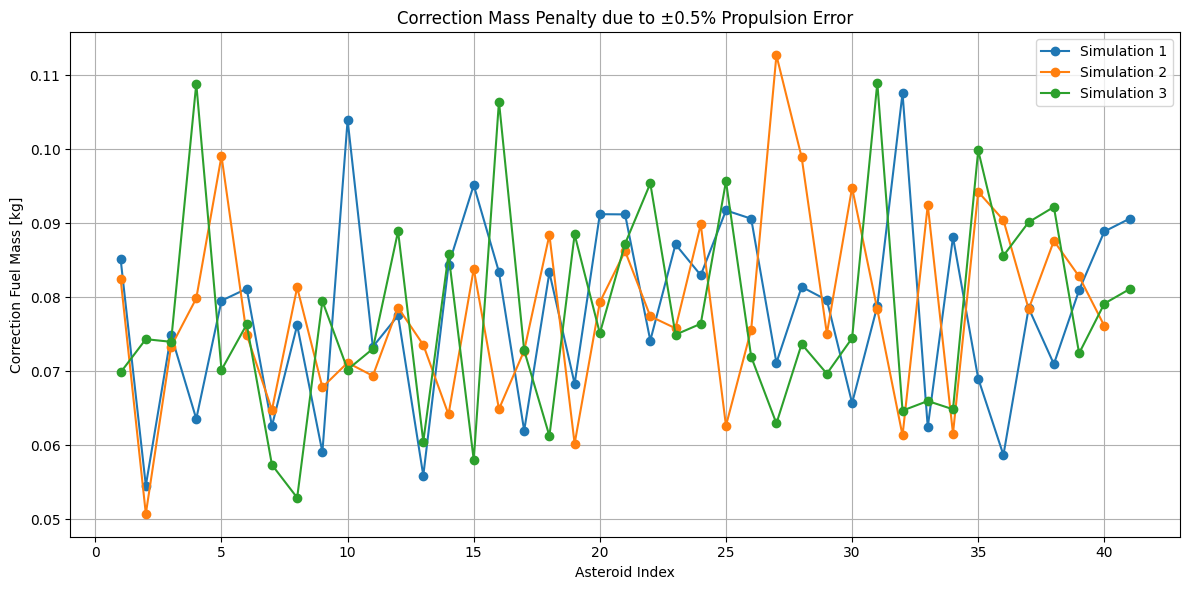

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Constants
mu_earth = 3.986004419e14  # [m^3/s^2]
g0 = 9.80665  # [m/s^2]
Isp = 1500  # [s], assumed specific impulse
m0 = 75.0  # [kg], initial spacecraft mass
delta_v_error_fraction = 0.005  # ±0.5%
time_error = 6 * 24 * 3600  # 6 days in seconds

# File names
nominal_files = ["nominal_sequence_1.txt", "nominal_sequence_2.txt", "nominal_sequence_3.txt"]
orbit_files = ["orbits_list_1.txt", "orbits_list_2.txt", "orbits_list_3.txt"]

# Functions
def extract_dv_values(filepath):
    dv_values = []
    with open(filepath, "r") as f:
        for line in f:
            if "DVT" in line and "Accepted" in line:
                dv_str = line.split("DVT = ")[1].split(" ")[0]
                dv_values.append(float(dv_str))  # in km/s
    return dv_values

def extract_sma_transfer_arcs(filepath):
    sma_list = []
    with open(filepath, "r") as f:
        for idx, line in enumerate(f):
            if line.startswith("#") or len(line.strip()) == 0:
                continue
            parts = line.strip().split()
            try:
                sma = float(parts[5])
                if (idx % 3) == 2:  # every 3rd orbit is transfer
                    sma_list.append(sma)
            except:
                continue
    return sma_list

def compute_phase_and_dv_error(sma_list, dv_list, t_error, error_frac):
    results = []
    for sma, dv in zip(sma_list, dv_list):
        n = np.sqrt(mu_earth / sma**3)  # mean motion [rad/s]
        dtheta_rad = n * t_error * error_frac
        dtheta_km = sma * dtheta_rad / 1000.0  # arc length in km
        sman = sma - (dtheta_km * 1000) / 2
        v_nom = np.sqrt(mu_earth * (2 / sma - 1 / sma))
        v_perturbed = np.sqrt(mu_earth * (2 / sma - 1 / sman))
        dvcorr = 10*abs(v_perturbed - v_nom) / 1000.0  # convert to km/s
        results.append((dtheta_km, dvcorr))
    return results

def compute_mass_penalty(dv_corrections, m0, Isp, g0):
    mass_used = []
    for dv in dv_corrections:
        mf = m0 / np.exp(dv * 1000 / (g0 * Isp))
        mass_used.append(m0 - mf)
    return mass_used

# Run analysis
all_dtheta_km = []
all_dvcorr_km_s = []
all_mass_used = []
labels = []

for i in range(3):
    dv_vals = extract_dv_values(nominal_files[i])
    sma_vals = extract_sma_transfer_arcs(orbit_files[i])
    results = compute_phase_and_dv_error(sma_vals[:len(dv_vals)], dv_vals, time_error, delta_v_error_fraction)
    
    dtheta_km = [r[0] for r in results]
    dvcorr_km_s = [r[1] for r in results]
    mass_used = compute_mass_penalty(dvcorr_km_s, m0, Isp, g0)
    
    all_dtheta_km.append(dtheta_km)
    all_dvcorr_km_s.append(dvcorr_km_s)
    all_mass_used.append(mass_used)
    labels.append(f"Simulation {i+1}")

    total_dv_penalty = sum(dvcorr_km_s)  # [km/s]
    total_mass_penalty = sum(mass_used)  # [kg]

    print(f"\nSimulation {i+1}")
    print(f"Total ΔV penalty: {total_dv_penalty:.4f} km/s")
    print(f"Total correction fuel used: {total_mass_penalty:.2f} kg")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    ax1.plot(range(1, len(all_dtheta_km[i]) + 1), all_mass_used[i],
             marker='o', linestyle='-', label=f"{labels[i]}")
ax1.set_xlabel("Asteroid Index")
ax1.set_ylabel("Correction Fuel Mass [kg]")
ax1.set_title("Correction Mass Penalty due to ±0.5% Propulsion Error")
ax1.grid(True)
ax1.legend()
plt.tight_layout()
plt.savefig("prop_error_mass_penalty.pdf")
plt.show()

In [34]:
import numpy as np
import pandas as pd

# Constants
mu_earth = 3.986004419e14  # m^3/s^2
delta_v_error_fraction = 0.005  # ±0.5%
time_error = 6 * 24 * 3600  # 6 days in seconds
dv_threshold_mps = 35  # 35 m/s threshold for acceptance

# File names
nominal_files = ["nominal_sequence_1.txt", "nominal_sequence_2.txt", "nominal_sequence_3.txt"]
orbit_files = ["orbits_list_1.txt", "orbits_list_2.txt", "orbits_list_3.txt"]

# Functions
def extract_dv_values(filepath):
    dv_values = []
    with open(filepath, "r") as f:
        for line in f:
            if "DVT" in line and "Accepted" in line:
                dv_str = line.split("DVT = ")[1].split(" ")[0]
                dv_values.append(float(dv_str))  # in km/s
    return dv_values

def extract_sma_transfer_arcs(filepath):
    sma_list = []
    with open(filepath, "r") as f:
        for idx, line in enumerate(f):
            if line.startswith("#") or len(line.strip()) == 0:
                continue
            parts = line.strip().split()
            try:
                sma = float(parts[5])
                if (idx % 3) == 2:  # every 3rd orbit is transfer
                    sma_list.append(sma)
            except:
                continue
    return sma_list

def compute_phase_and_dv_error(sma_list, dv_list, t_error, error_frac):
    results = []
    for idx, (sma, dv) in enumerate(zip(sma_list, dv_list), start=1):
        n = np.sqrt(mu_earth / sma**3)
        dtheta_rad = n * t_error * error_frac
        dtheta_deg = np.degrees(dtheta_rad)
        dtheta_km = sma * dtheta_rad
        sman = sma - dtheta_km/2
        dvcorr = 20 * abs(np.sqrt(mu_earth*(2/sma - 1/sman)) - np.sqrt(mu_earth/sma))
        accept = dvcorr < dv_threshold_mps
        results.append([idx, dtheta_deg, dtheta_km/1000, dvcorr, "Accepted" if accept else "Rejected"])
    return results

def filter_and_summarize_rejected(df):
    rejected_df = df[df["Status"] == "Rejected"].copy()
    
    if rejected_df.empty:
        print("No rejected trajectories. All ΔV corrections are below the threshold.")
    else:
        print("\n--- Rejected Trajectories Summary ---")
        print(f"Total Rejected: {len(rejected_df)} out of {len(df)}")
        print("\nSummary Statistics (Rejected Only):")
        print(rejected_df.describe())
    
    return rejected_df

def run_analysis(nominal_files, orbit_files, t_error, error_frac):
    all_dfs = []
    for i, (nf, of) in enumerate(zip(nominal_files, orbit_files)):
        dv_vals = extract_dv_values(nf)
        sma_vals = extract_sma_transfer_arcs(of)
        result = compute_phase_and_dv_error(sma_vals[:len(dv_vals)], dv_vals, t_error, error_frac)
        df = pd.DataFrame(result, columns=["Asteroid #", "Phase Shift [deg]", "Phase Shift [km]", "Correction ΔV [m/s]", "Status"])
        df.insert(0, "Simulation", f"Sim {i+1}")
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)

if __name__ == "__main__":
    table = run_analysis(nominal_files, orbit_files, time_error, delta_v_error_fraction)
    print(table.to_string(index=False))
    table.to_csv("propulsion_error_summary.csv", index=False)
    rejected_table = filter_and_summarize_rejected(table)
    rejected_table.to_csv("propulsion_error_rejected.csv", index=False)
    print("\n--- Rejected Trajectories ---")
    print(rejected_table.to_string(index=False))

Simulation  Asteroid #  Phase Shift [deg]  Phase Shift [km]  Correction ΔV [m/s]   Status
     Sim 1           1           0.379225       2607.318298            33.427509 Accepted
     Sim 1           2           0.271725       2333.126834            21.407698 Accepted
     Sim 1           3           0.344560       2525.322479            29.405615 Accepted
     Sim 1           4           0.304677       2423.865013            24.946346 Accepted
     Sim 1           5           0.360285       2563.167690            31.213737 Accepted
     Sim 1           6           0.365749       2576.059983            31.848396 Accepted
     Sim 1           7           0.301225       2414.674307            24.569202 Accepted
     Sim 1           8           0.348994       2536.107856            29.912648 Accepted
     Sim 1           9           0.288406       2379.924306            23.181869 Accepted
     Sim 1          10           0.440113       2739.994659            40.795901 Rejected
     Sim 1